# Local YOLO whole-bottle confidence audit

Локальная проверка YOLO11x instance segmentation для будущего bottle reranker. По умолчанию notebook обрабатывает реальные фотографии из `datasets/real_photos_v4/queries`, делает **один whole-bottle crop на изображение** и сохраняет 30 самых неуверенных и 10 самых уверенных результатов.

Важно: это аудит способности YOLO найти и сегментировать бутылку. В многобутылочном кадре здесь намеренно выбирается detection с максимальным YOLO confidence; это **не** финальная логика выбора целевой бутылки. В resolver целевая маска должна выбираться по принадлежности к label box / перекрестью пользователя.

Запускай notebook из project `.venv`. На Apple Silicon автоматически используется MPS, на NVIDIA — CUDA, иначе CPU. Первый запуск может скачать `yolo11x-seg.pt` в `models/bottle_reranker/`.

In [1]:
# Зависимости уже установлены в PROJECT_ROOT/.venv. Если создашь новое окружение,
# один раз выполни в терминале из корня проекта:
# .venv/bin/python -m pip install -r bottle_reranker/requirements.txt

In [2]:
from __future__ import annotations

import hashlib
import json
import math
import os
import platform
import shutil
import sys
from pathlib import Path

import cv2
import numpy as np
import pandas as pd
import torch
from IPython.display import display
from PIL import Image, ImageDraw, ImageFont, ImageOps
from tqdm.auto import tqdm
from ultralytics import YOLO

# ---------------------------------------------------------------- parameters
PROJECT_ROOT = Path("/Users/konstantinmelnikov/Desktop/work/VIscaNEr").resolve()

# Default: the real-photo pool. To audit the synthetic 45k pool instead, use:
# IMAGE_ROOT = PROJECT_ROOT / "datasets" / "bottle_images_45k"
IMAGE_ROOT = PROJECT_ROOT / "datasets" / "real_photos_v4" / "queries"
MAX_IMAGES: int | None = None  # e.g. 100 for a quick local smoke run

MODEL_NAME = "yolo11x-seg.pt"
MODEL_DIR = PROJECT_ROOT / "models" / "bottle_reranker"
OUTPUT_ROOT = PROJECT_ROOT / "bottle_reranker" / "outputs" / "yolo_bottle_confidence_audit"
RESET_OUTPUT = False  # True deliberately removes this audit's old checkpoints/results.

IMAGE_SIZE = 1024
INFERENCE_CONFIDENCE_FLOOR = 0.001
IOU_THRESHOLD = 0.70
BOTTLE_CLASS_ID = 39  # COCO: bottle
PAD_FRACTION = 0.06
LOWEST_N = 30
HIGHEST_N = 10
CHECKPOINT_EVERY = 250

if not PROJECT_ROOT.is_dir():
    raise FileNotFoundError(f"PROJECT_ROOT does not exist: {PROJECT_ROOT}")
if not IMAGE_ROOT.is_dir():
    raise FileNotFoundError(f"IMAGE_ROOT does not exist: {IMAGE_ROOT}")

if torch.cuda.is_available():
    DEVICE = 0
    DEVICE_NAME = torch.cuda.get_device_name(0)
    USE_HALF = True
    BATCH_SIZE = 8
elif torch.backends.mps.is_available():
    DEVICE = "mps"
    DEVICE_NAME = "Apple Metal (MPS)"
    USE_HALF = False
    BATCH_SIZE = 2
else:
    DEVICE = "cpu"
    DEVICE_NAME = platform.processor() or "CPU"
    USE_HALF = False
    BATCH_SIZE = 1

if RESET_OUTPUT and OUTPUT_ROOT.exists():
    shutil.rmtree(OUTPUT_ROOT)
MODEL_DIR.mkdir(parents=True, exist_ok=True)
OUTPUT_ROOT.mkdir(parents=True, exist_ok=True)
PREDICTIONS_CSV = OUTPUT_ROOT / "all_predictions.csv"
RUN_METADATA_JSON = OUTPUT_ROOT / "run_metadata.json"

print(f"Python:      {sys.version.split()[0]}")
print(f"PyTorch:     {torch.__version__}")
print(f"Ultralytics: {__import__('ultralytics').__version__}")
print(f"Device:      {DEVICE_NAME} ({DEVICE})")
print(f"Batch size:  {BATCH_SIZE}")
print(f"Input:       {IMAGE_ROOT}")
print(f"Output:      {OUTPUT_ROOT}")

Python:      3.12.14
PyTorch:     2.14.0
Ultralytics: 8.4.154
Device:      Apple Metal (MPS) (mps)
Batch size:  2
Input:       /Users/konstantinmelnikov/Desktop/work/VIscaNEr/datasets/real_photos_v4/queries
Output:      /Users/konstantinmelnikov/Desktop/work/VIscaNEr/bottle_reranker/outputs/yolo_bottle_confidence_audit


In [3]:
def discover_images(image_root: Path) -> list[Path]:
    extensions = {".jpg", ".jpeg", ".png", ".webp", ".bmp", ".tif", ".tiff"}
    excluded_parts = {
        "mask", "masks", "masks_npz", "normalized", "top",
        "reference", "references", "audit", "outputs", "__macosx",
    }
    files = []
    for path in image_root.rglob("*"):
        if not path.is_file() or path.suffix.lower() not in extensions:
            continue
        relative_parts = {part.lower() for part in path.relative_to(image_root).parts[:-1]}
        if relative_parts & excluded_parts:
            continue
        files.append(path)
    files = sorted(files)
    if MAX_IMAGES is not None:
        if MAX_IMAGES <= 0:
            raise ValueError("MAX_IMAGES must be positive or None")
        files = files[:MAX_IMAGES]
    return files


IMAGE_PATHS = discover_images(IMAGE_ROOT)
if not IMAGE_PATHS:
    raise RuntimeError(f"No images found under {IMAGE_ROOT}")

print(f"Project root: {PROJECT_ROOT}")
print(f"Image root:   {IMAGE_ROOT}")
print(f"Images:       {len(IMAGE_PATHS):,}")
print("First files:")
for sample in IMAGE_PATHS[:8]:
    print(" -", sample.relative_to(PROJECT_ROOT))

Project root: /Users/konstantinmelnikov/Desktop/work/VIscaNEr
Image root:   /Users/konstantinmelnikov/Desktop/work/VIscaNEr/datasets/real_photos_v4/queries
Images:       918
First files:
 - datasets/real_photos_v4/queries/q-0001.jpg
 - datasets/real_photos_v4/queries/q-0002.jpg
 - datasets/real_photos_v4/queries/q-0003.jpg
 - datasets/real_photos_v4/queries/q-0004.jpg
 - datasets/real_photos_v4/queries/q-0005.jpg
 - datasets/real_photos_v4/queries/q-0006.jpg
 - datasets/real_photos_v4/queries/q-0007.jpg
 - datasets/real_photos_v4/queries/q-0008.jpg


## Load YOLO11x-seg locally

The ranking uses the confidence of the highest-confidence COCO `bottle` instance in each image. The crop bounds come from that instance mask with 6% padding, so the neck and cap remain inside the single whole-bottle crop. Weights are reused from `models/bottle_reranker/yolo11x-seg.pt`; when absent, Ultralytics downloads them there once.

In [4]:
local_weights = MODEL_DIR / MODEL_NAME
if local_weights.is_file():
    model = YOLO(str(local_weights))
else:
    # Keep the automatic download inside the project model directory.
    previous_cwd = Path.cwd()
    try:
        os.chdir(MODEL_DIR)
        model = YOLO(MODEL_NAME)
    finally:
        os.chdir(previous_cwd)

resolved_weights = Path(str(getattr(model, "ckpt_path", local_weights))).resolve()
if not resolved_weights.is_file() and local_weights.is_file():
    resolved_weights = local_weights
weights_sha256 = None
if resolved_weights.is_file():
    digest = hashlib.sha256()
    with resolved_weights.open("rb") as handle:
        for chunk in iter(lambda: handle.read(1024 * 1024), b""):
            digest.update(chunk)
    weights_sha256 = digest.hexdigest()

run_metadata = {
    "project_root": str(PROJECT_ROOT),
    "image_root": str(IMAGE_ROOT),
    "image_count": len(IMAGE_PATHS),
    "max_images": MAX_IMAGES,
    "model_path": str(resolved_weights),
    "weights_sha256": weights_sha256,
    "image_size": IMAGE_SIZE,
    "confidence_floor": INFERENCE_CONFIDENCE_FLOOR,
    "iou_threshold": IOU_THRESHOLD,
    "bottle_class_id": BOTTLE_CLASS_ID,
    "pad_fraction": PAD_FRACTION,
    "device": str(DEVICE),
    "half": USE_HALF,
    "batch_size": BATCH_SIZE,
}
if RUN_METADATA_JSON.exists():
    previous_metadata = json.loads(RUN_METADATA_JSON.read_text())
    if previous_metadata != run_metadata:
        raise RuntimeError(
            "Existing checkpoint belongs to different settings. Move or delete "
            f"{OUTPUT_ROOT} before starting a new audit."
        )
else:
    RUN_METADATA_JSON.write_text(json.dumps(run_metadata, indent=2))

print(json.dumps(run_metadata, indent=2))

{
  "project_root": "/Users/konstantinmelnikov/Desktop/work/VIscaNEr",
  "image_root": "/Users/konstantinmelnikov/Desktop/work/VIscaNEr/datasets/real_photos_v4/queries",
  "image_count": 918,
  "max_images": null,
  "model_path": "/Users/konstantinmelnikov/Desktop/work/VIscaNEr/models/bottle_reranker/yolo11x-seg.pt",
  "weights_sha256": "4e53a5f5fd3ee2ae3361c62169c6bb3ed4ae251dd0e57606e230955aa52d919c",
  "image_size": 1024,
  "confidence_floor": 0.001,
  "iou_threshold": 0.7,
  "bottle_class_id": 39,
  "pad_fraction": 0.06,
  "device": "mps",
  "half": false,
  "batch_size": 2
}


In [5]:
def load_rgb(path: Path) -> np.ndarray:
    with Image.open(path) as image:
        return np.asarray(ImageOps.exif_transpose(image).convert("RGB"))


def padded_mask_bbox(result, index: int, width: int, height: int) -> tuple[int, int, int, int]:
    mask = result.masks.data[index].detach().float().cpu().numpy()
    if mask.shape != (height, width):
        mask = cv2.resize(mask, (width, height), interpolation=cv2.INTER_NEAREST)
    ys, xs = np.where(mask > 0.5)
    if len(xs):
        x1, y1, x2, y2 = int(xs.min()), int(ys.min()), int(xs.max()) + 1, int(ys.max()) + 1
    else:
        x1, y1, x2, y2 = map(int, result.boxes.xyxy[index].detach().cpu().tolist())
    pad = int(round(max(x2 - x1, y2 - y1) * PAD_FRACTION))
    return max(0, x1 - pad), max(0, y1 - pad), min(width, x2 + pad), min(height, y2 + pad)


def write_checkpoint(rows: list[dict]) -> pd.DataFrame:
    frame = pd.DataFrame(rows)
    frame = frame.drop_duplicates(subset=["relative_path"], keep="last")
    frame = frame.sort_values("relative_path").reset_index(drop=True)
    frame.to_csv(PREDICTIONS_CSV, index=False)
    return frame


if PREDICTIONS_CSV.exists():
    existing = pd.read_csv(PREDICTIONS_CSV)
    rows = existing.to_dict(orient="records")
    completed = set(existing["relative_path"].astype(str))
    print(f"Resuming: {len(completed):,} images already recorded")
else:
    rows = []
    completed = set()

pending = [p for p in IMAGE_PATHS if p.relative_to(PROJECT_ROOT).as_posix() not in completed]
processed_since_checkpoint = 0

for offset in tqdm(range(0, len(pending), BATCH_SIZE), desc="YOLO bottle segmentation"):
    batch_paths = pending[offset : offset + BATCH_SIZE]
    batch_arrays = []
    valid_paths = []

    for path in batch_paths:
        relative = path.relative_to(PROJECT_ROOT).as_posix()
        try:
            rgb = load_rgb(path)
            batch_arrays.append(rgb[:, :, ::-1].copy())  # contiguous RGB -> BGR
            valid_paths.append((path, relative, rgb.shape[1], rgb.shape[0]))
        except Exception as error:
            rows.append({
                "relative_path": relative, "status": "decode_error",
                "error": f"{type(error).__name__}: {error}",
            })

    if batch_arrays:
        results = model.predict(
            source=batch_arrays,
            imgsz=IMAGE_SIZE,
            conf=INFERENCE_CONFIDENCE_FLOOR,
            iou=IOU_THRESHOLD,
            classes=[BOTTLE_CLASS_ID],
            retina_masks=True,
            device=DEVICE,
            half=USE_HALF,
            verbose=False,
        )

        for (path, relative, width, height), result in zip(valid_paths, results):
            if result.boxes is None or result.masks is None or len(result.boxes) == 0:
                rows.append({
                    "relative_path": relative, "status": "no_detection",
                    "image_width": width, "image_height": height,
                    "detections_count": 0,
                })
                continue

            confidences = result.boxes.conf.detach().float().cpu().numpy()
            selected = int(np.argmax(confidences))
            confidence = float(confidences[selected])
            x1, y1, x2, y2 = padded_mask_bbox(result, selected, width, height)
            rows.append({
                "relative_path": relative,
                "status": "detected",
                "image_width": width,
                "image_height": height,
                "detections_count": int(len(confidences)),
                "yolo_confidence": confidence,
                "uncertainty": 1.0 - confidence,
                "crop_x1": x1, "crop_y1": y1, "crop_x2": x2, "crop_y2": y2,
            })

    processed_since_checkpoint += len(batch_paths)
    if processed_since_checkpoint >= CHECKPOINT_EVERY:
        write_checkpoint(rows)
        processed_since_checkpoint = 0

predictions = write_checkpoint(rows)
print(predictions["status"].value_counts(dropna=False))
print(f"Saved: {PREDICTIONS_CSV}")

YOLO bottle segmentation:   0%|          | 0/459 [00:00<?, ?it/s]

WARNING ⚠️ 'half' is deprecated and will be removed in the future. Use 'quantize' instead.
WARNING ⚠️ 'half' is deprecated and will be removed in the future. Use 'quantize' instead.
WARNING ⚠️ 'half' is deprecated and will be removed in the future. Use 'quantize' instead.
WARNING ⚠️ 'half' is deprecated and will be removed in the future. Use 'quantize' instead.
WARNING ⚠️ 'half' is deprecated and will be removed in the future. Use 'quantize' instead.
WARNING ⚠️ 'half' is deprecated and will be removed in the future. Use 'quantize' instead.
WARNING ⚠️ 'half' is deprecated and will be removed in the future. Use 'quantize' instead.
WARNING ⚠️ 'half' is deprecated and will be removed in the future. Use 'quantize' instead.
WARNING ⚠️ 'half' is deprecated and will be removed in the future. Use 'quantize' instead.
WARNING ⚠️ 'half' is deprecated and will be removed in the future. Use 'quantize' instead.
WARNING ⚠️ 'half' is deprecated and will be removed in the future. Use 'quantize' instead.

In [6]:
valid = predictions[predictions["status"] == "detected"].copy()
valid["yolo_confidence"] = pd.to_numeric(valid["yolo_confidence"], errors="coerce")
valid = valid.dropna(subset=["yolo_confidence"])
if len(valid) < LOWEST_N + HIGHEST_N:
    raise RuntimeError(
        f"Need at least {LOWEST_N + HIGHEST_N} valid detections, found {len(valid)}"
    )

least_confident = valid.nsmallest(LOWEST_N, "yolo_confidence").copy()
most_confident = valid.nlargest(HIGHEST_N, "yolo_confidence").copy()
least_confident["group"] = "least_confident"
most_confident["group"] = "most_confident"
least_confident["rank"] = range(1, len(least_confident) + 1)
most_confident["rank"] = range(1, len(most_confident) + 1)
selected = pd.concat([least_confident, most_confident], ignore_index=True)

for directory_name in ("least_confident_30", "most_confident_10"):
    directory = OUTPUT_ROOT / directory_name
    if directory.exists():
        shutil.rmtree(directory)
    directory.mkdir(parents=True)

crop_paths = []
for row_index, row in selected.iterrows():
    source_path = PROJECT_ROOT / row["relative_path"]
    rgb = load_rgb(source_path)
    x1, y1, x2, y2 = (int(row[key]) for key in ("crop_x1", "crop_y1", "crop_x2", "crop_y2"))
    crop = Image.fromarray(rgb[y1:y2, x1:x2])
    short_hash = hashlib.sha1(row["relative_path"].encode()).hexdigest()[:8]
    directory_name = "least_confident_30" if row["group"] == "least_confident" else "most_confident_10"
    filename = (
        f"{int(row['rank']):02d}_conf-{float(row['yolo_confidence']):.4f}_"
        f"{short_hash}_{source_path.stem}.jpg"
    )
    destination = OUTPUT_ROOT / directory_name / filename
    crop.save(destination, quality=95, subsampling=0)
    crop_paths.append(destination.relative_to(OUTPUT_ROOT).as_posix())

selected["crop_path"] = crop_paths
selected.to_csv(OUTPUT_ROOT / "selected_crops.csv", index=False)
least_confident = selected[selected["group"] == "least_confident"].sort_values("rank").copy()
most_confident = selected[selected["group"] == "most_confident"].sort_values("rank").copy()
predictions[predictions["status"] == "no_detection"].to_csv(
    OUTPUT_ROOT / "no_detection.csv", index=False
)

display(selected[["group", "rank", "yolo_confidence", "relative_path", "crop_path"]])

,group,rank,yolo_confidence,relative_path,crop_path
0,least_confident,1,0.001053,datasets/real_photos_v4/queries/q-0463.jpg,least_confident_30/01_conf-0.0011_3ece2765_q-0...
1,least_confident,2,0.001106,datasets/real_photos_v4/queries/q-0696.jpg,least_confident_30/02_conf-0.0011_42d07b35_q-0...
2,least_confident,3,0.001327,datasets/real_photos_v4/queries/q-0798.jpg,least_confident_30/03_conf-0.0013_ce17e598_q-0...
3,least_confident,4,0.001350,datasets/real_photos_v4/queries/q-0673.jpg,least_confident_30/04_conf-0.0013_51e30bb5_q-0...
4,least_confident,5,0.001374,datasets/real_photos_v4/queries/q-0537.jpg,least_confident_30/05_conf-0.0014_fe3adda7_q-0...
5,least_confident,6,0.001390,datasets/real_photos_v4/queries/q-0466.jpg,least_confident_30/06_conf-0.0014_80fb6887_q-0...
6,least_confident,7,0.001410,datasets/real_photos_v4/queries/q-0054.jpg,least_confident_30/07_conf-0.0014_37e662d8_q-0...
7,least_confident,8,0.001434,datasets/real_photos_v4/queries/q-0698.jpg,least_confident_30/08_conf-0.0014_bc6a0083_q-0...
8,least_confident,9,0.001478,datasets/real_photos_v4/queries/q-0579.jpg,least_confident_30/09_conf-0.0015_2d4ab6a1_q-0...
9,least_confident,10,0.001487,datasets/real_photos_v4/queries/q-0761.jpg,least_confident_30/10_conf-0.0015_6cd35992_q-0...


{
  "images_scanned": 918,
  "valid_bottle_detections": 836,
  "no_detection": 82,
  "decode_errors": 0,
  "least_confident_count": 30,
  "most_confident_count": 10,
  "least_confident_range": [
    0.0010528784478083253,
    0.009200111031532288
  ],
  "most_confident_range": [
    0.9820302128791809,
    0.9873491525650024
  ]
}
Archive: /Users/konstantinmelnikov/Desktop/work/VIscaNEr/bottle_reranker/outputs/yolo_bottle_confidence_audit.zip


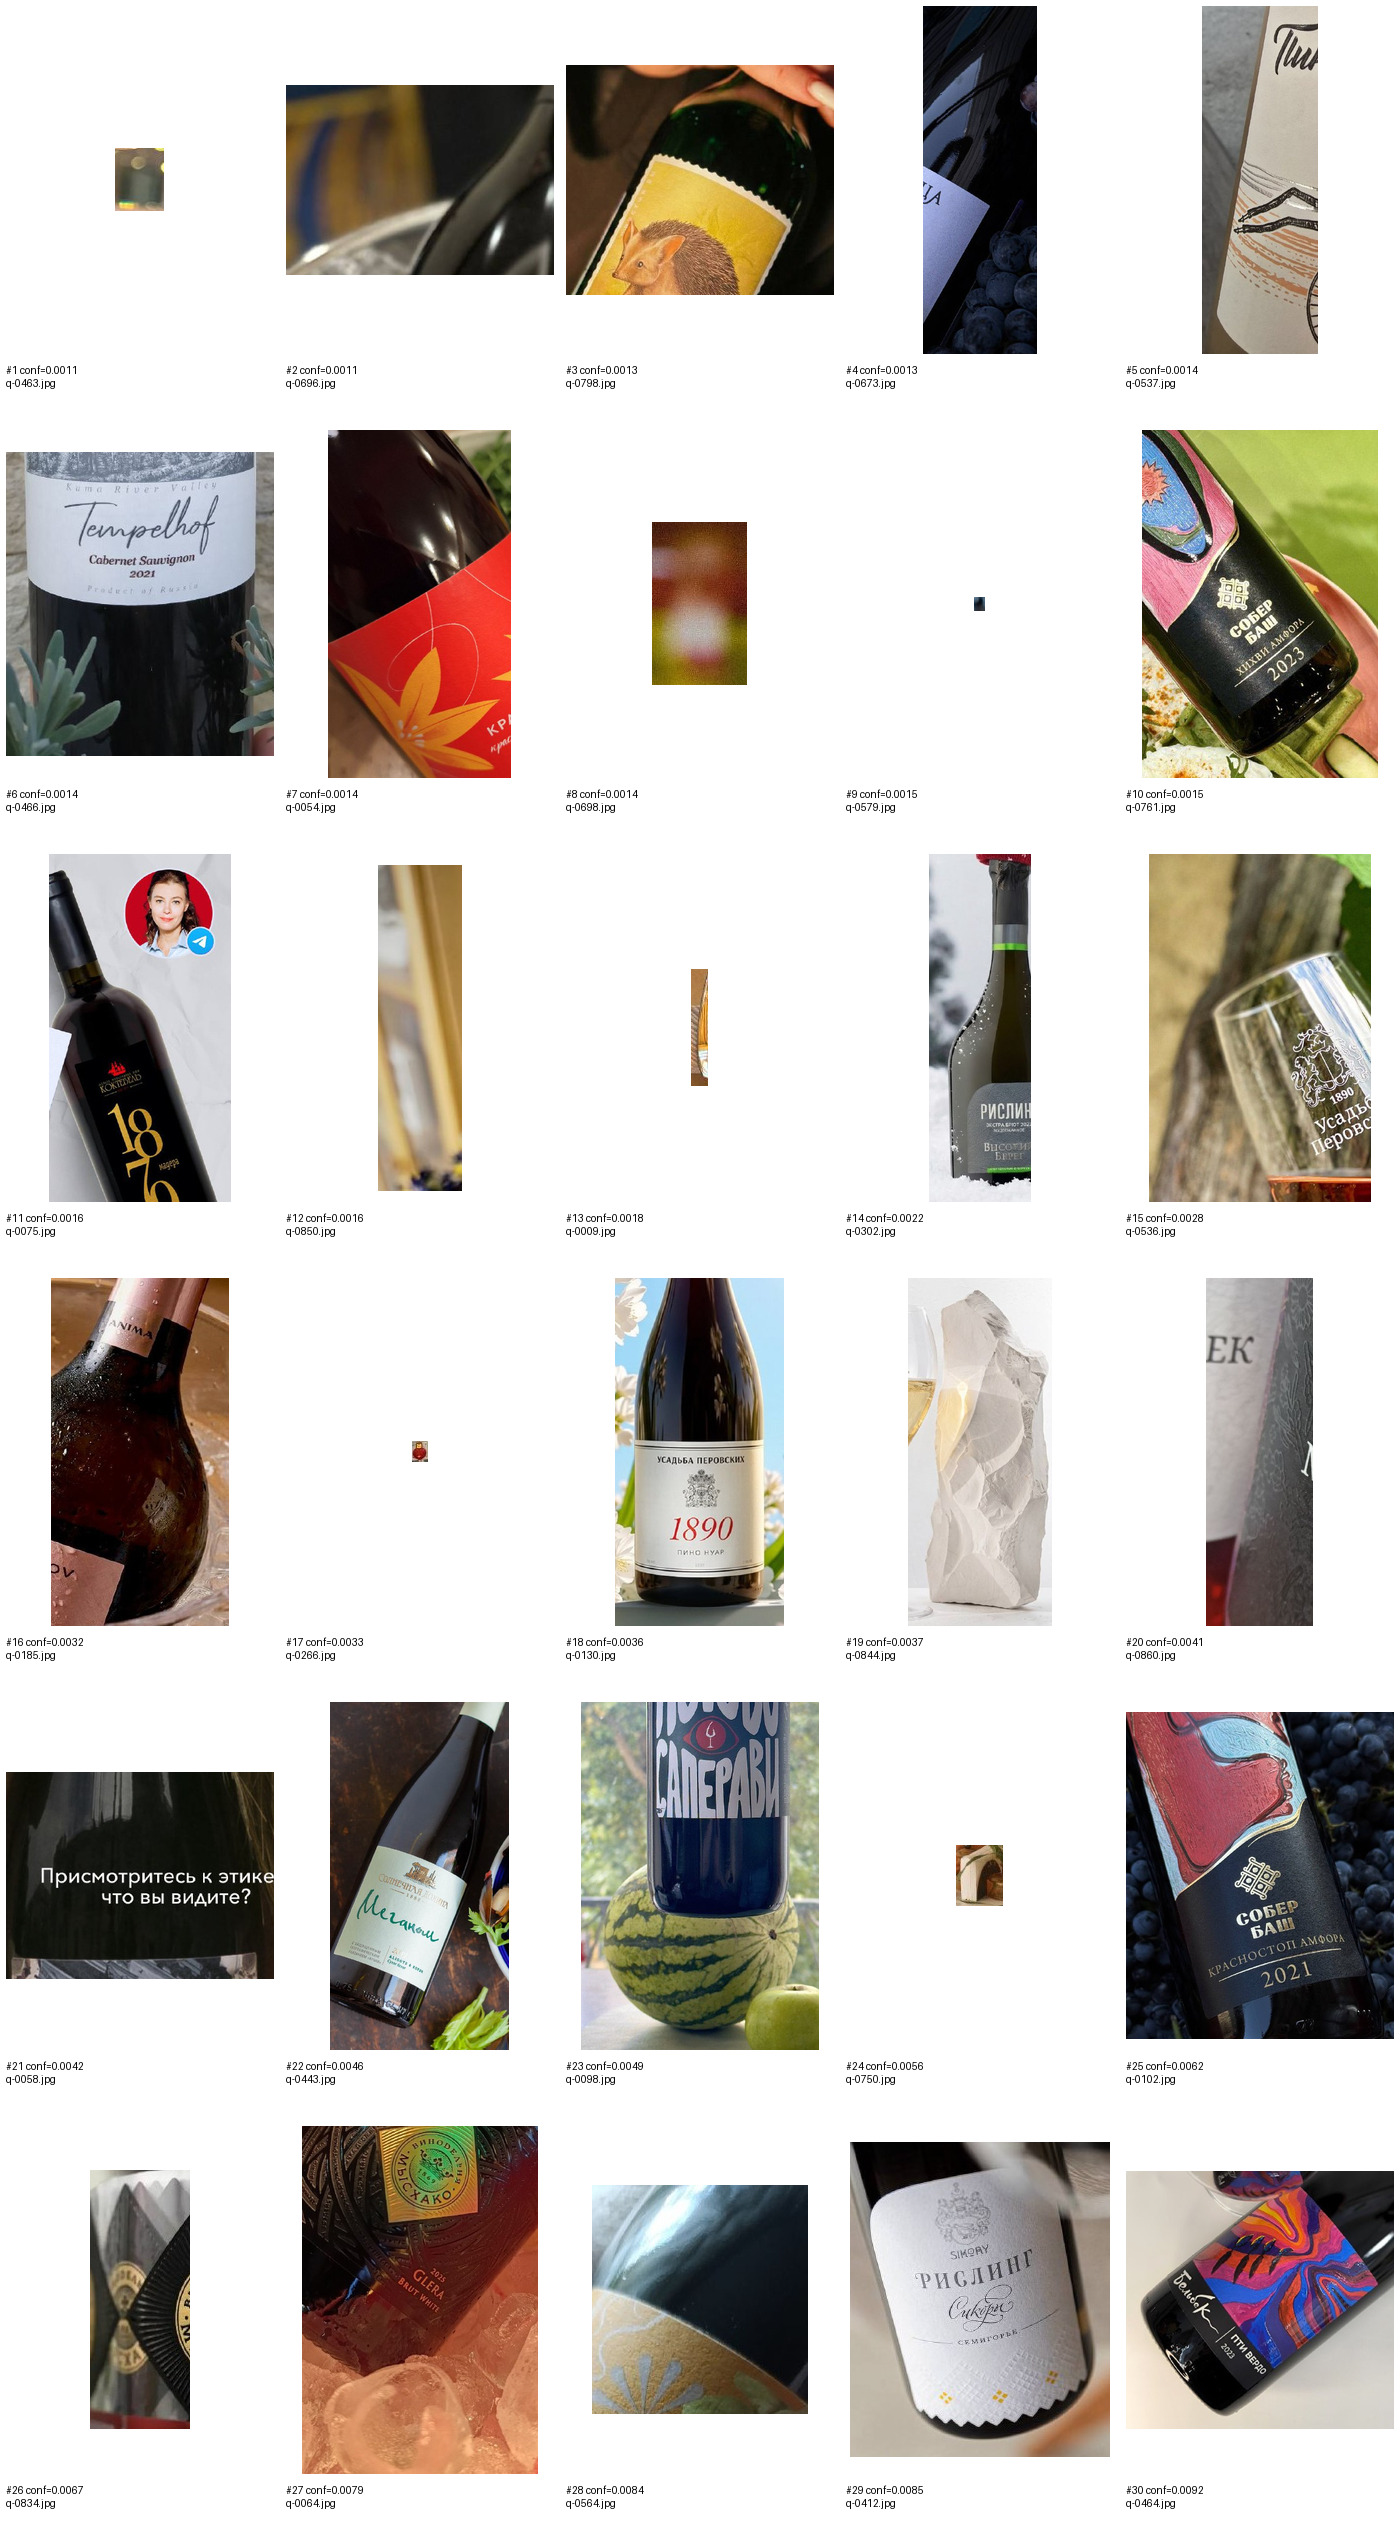

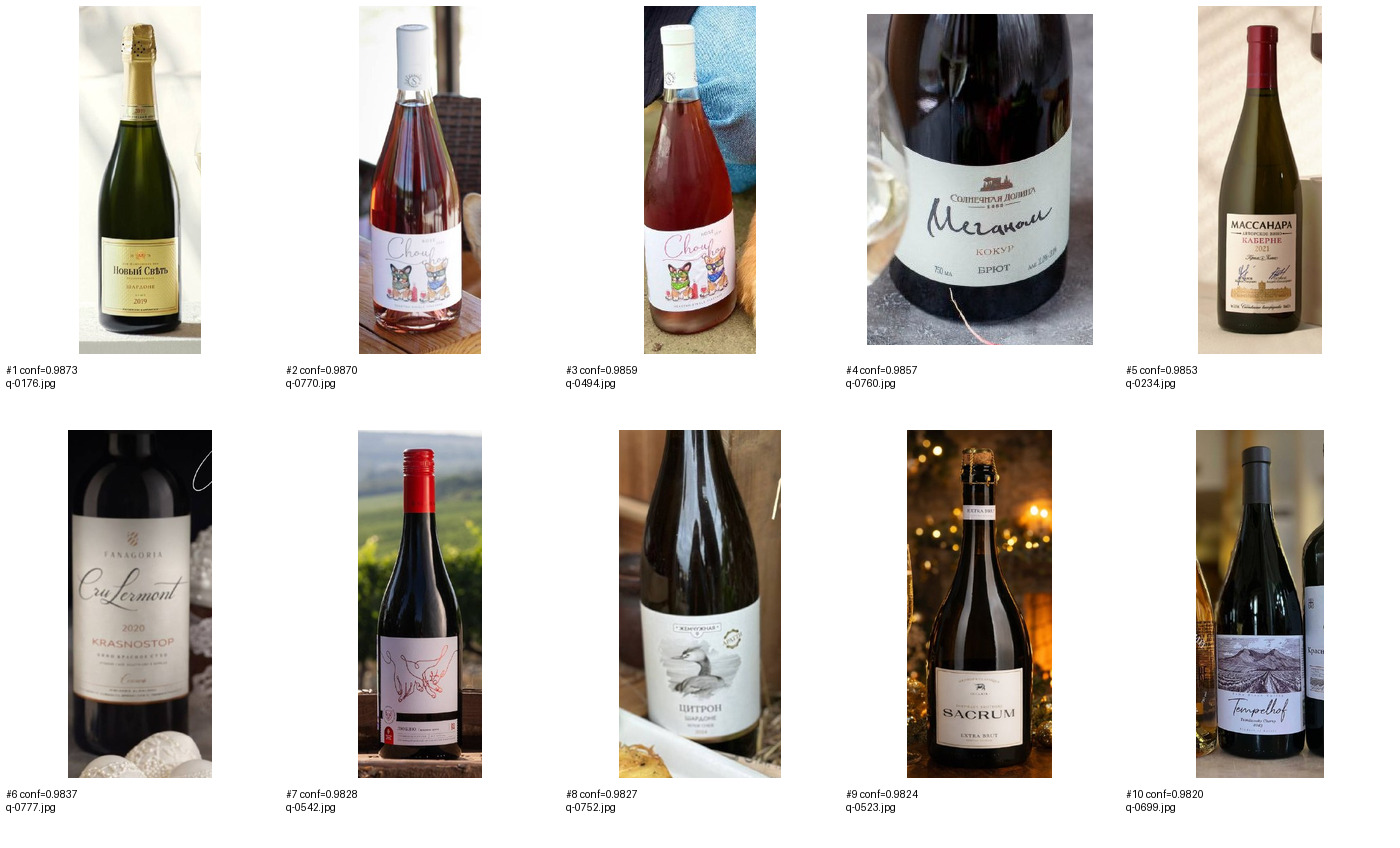

In [7]:
def make_contact_sheet(rows: pd.DataFrame, destination: Path, columns: int = 5) -> Path:
    tile_width, tile_height, caption_height = 280, 360, 64
    sheet_rows = math.ceil(len(rows) / columns)
    sheet = Image.new("RGB", (columns * tile_width, sheet_rows * (tile_height + caption_height)), "white")
    draw = ImageDraw.Draw(sheet)
    font = ImageFont.load_default()

    for position, (_, row) in enumerate(rows.iterrows()):
        crop = Image.open(OUTPUT_ROOT / row["crop_path"]).convert("RGB")
        crop.thumbnail((tile_width - 12, tile_height - 12), Image.Resampling.LANCZOS)
        x0 = (position % columns) * tile_width
        y0 = (position // columns) * (tile_height + caption_height)
        paste_x = x0 + (tile_width - crop.width) // 2
        paste_y = y0 + (tile_height - crop.height) // 2
        sheet.paste(crop, (paste_x, paste_y))
        caption = f"#{int(row['rank'])} conf={float(row['yolo_confidence']):.4f}\n{Path(row['relative_path']).name[:38]}"
        draw.multiline_text((x0 + 6, y0 + tile_height + 4), caption, fill="black", font=font, spacing=3)

    sheet.save(destination, quality=92, subsampling=0)
    return destination


least_sheet = make_contact_sheet(least_confident, OUTPUT_ROOT / "least_confident_30.jpg")
most_sheet = make_contact_sheet(most_confident, OUTPUT_ROOT / "most_confident_10.jpg")

summary = {
    "images_scanned": int(len(predictions)),
    "valid_bottle_detections": int((predictions["status"] == "detected").sum()),
    "no_detection": int((predictions["status"] == "no_detection").sum()),
    "decode_errors": int((predictions["status"] == "decode_error").sum()),
    "least_confident_count": int(len(least_confident)),
    "most_confident_count": int(len(most_confident)),
    "least_confident_range": [
        float(least_confident["yolo_confidence"].min()),
        float(least_confident["yolo_confidence"].max()),
    ],
    "most_confident_range": [
        float(most_confident["yolo_confidence"].min()),
        float(most_confident["yolo_confidence"].max()),
    ],
}
(OUTPUT_ROOT / "summary.json").write_text(json.dumps(summary, indent=2))
archive = shutil.make_archive(str(OUTPUT_ROOT), "zip", root_dir=OUTPUT_ROOT)

print(json.dumps(summary, indent=2))
print(f"Archive: {archive}")
display(Image.open(least_sheet))
display(Image.open(most_sheet))

## Output

Results are saved under `bottle_reranker/outputs/yolo_bottle_confidence_audit/`; the ready archive is `bottle_reranker/outputs/yolo_bottle_confidence_audit.zip`. It contains the 40 selected whole-bottle crops, both contact sheets, the full prediction table, selected rows, no-detection rows, run settings, and the summary. Confidence values are raw YOLO instance confidences, not calibrated probabilities.